In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def lj(x, eps=1, sigma=1):
    """
    computes energy for a lennard jones potential
    """
    scaled_r = sigma/x
    return 4.0*eps*(scaled_r**12 - scaled_r**6)

In [3]:
eps = 1
sig = 1
x = np.linspace(0.98, 3, 100)

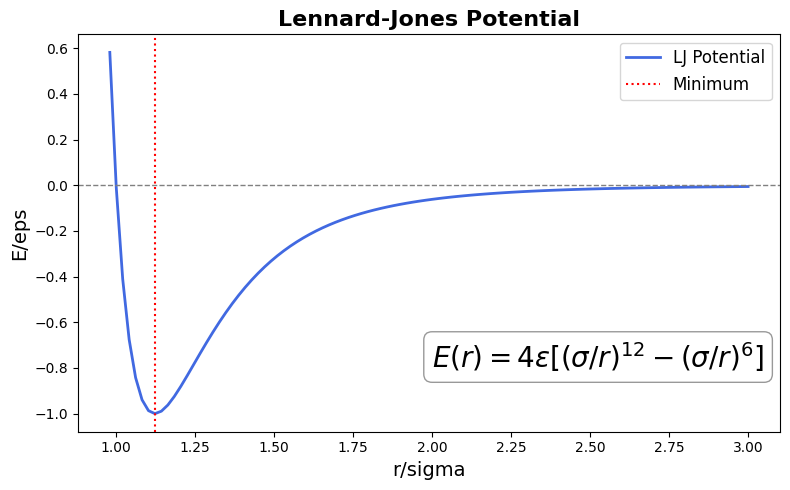

In [4]:
plt.style.use('seaborn-v0_8-dark-palette')
plt.figure(figsize=(8, 5))
plt.title("Lennard-Jones Potential", fontsize=16, fontweight='bold')
plt.plot(x, lj(x, sigma=sig, eps=eps)/eps, color='royalblue', linewidth=2, label='LJ Potential')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(2**(1/6)*sig, color='red', linestyle=':', linewidth=1.5, label='Minimum')
plt.ylabel("E/eps", fontsize=14)
plt.xlabel("r/sigma", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.annotate(
    "$E(r) = 4\\epsilon[(\\sigma/r)^{12} - (\\sigma/r)^6]$",
    xy=(2., -0.8), xycoords='data',
    fontsize=20, color='black',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)
plt.savefig("lennard_jones_potential.png", dpi=300)

In [5]:
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox

def interactive_lj_plot(num_samples=10, noise=0.0, prior=False):
    x_sampled = np.linspace(1.0, 1.8, num_samples)
    y_sampled = lj(x_sampled, sigma=sig, eps=eps) + noise * np.random.randn(len(x_sampled))

    plt.style.use('seaborn-v0_8-dark-palette')
    plt.figure(figsize=(8, 5))
    plt.title("Lennard-Jones Potential", fontsize=16, fontweight='bold')
    plt.plot(x, lj(x, sigma=sig, eps=eps)/eps, color='royalblue', linewidth=2, label='LJ Potential - ground truth')
    plt.ylabel("E/eps", fontsize=14)
    plt.xlabel("r/sigma", fontsize=14)

    plt.tight_layout()
    plt.scatter(x_sampled, y_sampled/eps, color='darkorange', s=100, edgecolor='k', zorder=5, label='Sampled Points')
    plt.ylim(-1.1, 0.6)
    plt.xlim(0.98, 2.2)
    
    for deg in [1, 4, 8, 12]:
        if prior:
            coeffs = np.polyfit(1/x_sampled, y_sampled, deg=deg)
            poly_fit = np.poly1d(coeffs)
            y_fit = poly_fit(1/x)
        else:
            coeffs = np.polyfit(x_sampled, y_sampled, deg=deg)
            poly_fit = np.poly1d(coeffs)
            y_fit = poly_fit(x)

        plt.plot(x, y_fit, linestyle='--', linewidth=2, label=f'{deg} Degree Poly Fit')

    plt.legend(fontsize=12)
    plt.show()

interact(
    interactive_lj_plot,
    num_samples=IntSlider(min=5, max=50, step=1, value=10, description='Samples'),
    noise=FloatSlider(min=0.0, max=0.2, step=0.01, value=0.0, description='Noise'),
    prior=Checkbox(value=False, description='Use Prior Knowledge')
)


interactive(children=(IntSlider(value=10, description='Samples', max=50, min=5), FloatSlider(value=0.0, descri…

<function __main__.interactive_lj_plot(num_samples=10, noise=0.0, prior=False)>

In [6]:
# Bias–Variance Tradeoff: Interactive (ipywidgets)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from ipywidgets import interact, IntSlider, FloatSlider, Checkbox, HBox, VBox

In [28]:
def true_function(x):
    # return np.sin(x) + 0.3 * x
    return lj(x)

def make_data(n_samples, noise_sigma, random_state):
    rng = np.random.RandomState(random_state)
    X = np.linspace(0.98, 3, n_samples).reshape(-1, 1)
    y = true_function(X).ravel() + rng.normal(0, noise_sigma, size=n_samples)
    return X, y

In [29]:
def mse_curves(max_degree, n_samples, noise_sigma, test_size, random_state, shuffle):
    X, y = make_data(n_samples, noise_sigma, random_state)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=random_state, shuffle=shuffle)

    degrees = list(range(1, max_degree + 1))
    tr, te = [], []
    for d in degrees:
        model = Pipeline([("poly", PolynomialFeatures(d, include_bias=False)),
                          ("lin", LinearRegression())])
        model.fit(Xtr, ytr)
        tr.append(mean_squared_error(ytr, model.predict(Xtr)))
        te.append(mean_squared_error(yte, model.predict(Xte)))

    plt.figure()
    plt.plot(degrees, tr, marker="o", label="Train MSE")
    plt.plot(degrees, te, marker="o", label="Test MSE")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("MSE")
    plt.title("Bias–Variance Tradeoff: Train vs Test Error")
    plt.legend(); plt.grid(True); plt.show()

def fit_curve(degree_view, n_samples, noise_sigma, test_size, random_state, shuffle):
    X, y = make_data(n_samples, noise_sigma, random_state)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=random_state, shuffle=shuffle)

    model = Pipeline([("poly", PolynomialFeatures(degree_view, include_bias=False)),
                      ("lin", LinearRegression())])
    model.fit(Xtr, ytr)

    X_dense = np.linspace(0.98, 3, 400).reshape(-1, 1)
    y_fit = model.predict(X_dense)

    plt.figure()
    plt.scatter(Xtr, ytr, s=18, alpha=0.7, label="Train")
    plt.scatter(Xte, yte, s=18, alpha=0.7, label="Test")
    plt.plot(X_dense, true_function(X_dense), linestyle="--", linewidth=2, label="True f(x)")
    plt.plot(X_dense, y_fit, linewidth=2, label=f"Fit (deg={degree_view})")
    plt.xlabel("x"); plt.ylabel("y"); plt.title(f"Model Fit (degree={degree_view})")
    plt.legend(); plt.grid(True); plt.show()

In [33]:
ui = VBox([
    HBox([
        IntSlider(value=300, min=40, max=400, step=10, description="n_samples"),
        FloatSlider(value=0.40, min=0.0, max=0.1, step=0.05, description="noise_sigma"),
        FloatSlider(value=0.3, min=0.1, max=0.6, step=0.05, description="test_size"),
    ]),
    HBox([
        IntSlider(value=20, min=1, max=50, step=1, description="max_degree"),
        IntSlider(value=5, min=1, max=50, step=1, description="degree_view"),
        IntSlider(value=0, min=0, max=10, step=1, description="random_state"),
        Checkbox(value=True, description="shuffle")
    ])
])

In [ ]:

_ = interact(
    mse_curves,
    max_degree=ui.children[1].children[0],
    n_samples=ui.children[0].children[0],
    noise_sigma=ui.children[0].children[1],
    test_size=ui.children[0].children[2],
    random_state=ui.children[1].children[2],
    shuffle=ui.children[1].children[3],
)

interactive(children=(IntSlider(value=20, description='max_degree', max=50, min=1), IntSlider(value=300, descr…

In [ ]:

_ = interact(
    fit_curve,
    degree_view=ui.children[1].children[1],
    n_samples=ui.children[0].children[0],
    noise_sigma=ui.children[0].children[1],
    test_size=ui.children[0].children[2],
    random_state=ui.children[1].children[2],
    shuffle=ui.children[1].children[3],
)

display(ui)


interactive(children=(IntSlider(value=5, description='degree_view', max=50, min=1), IntSlider(value=300, descr…